# Declarative geoprocessing pipelines (`pyramids.processing`)

This notebook teaches the **`pyramids.processing`** layer — a QGIS-Processing-style way to describe a
reusable, serializable **pipeline** of pyramids operations and run it (batched) over one or many inputs.

By the end you will be able to:

- discover the available **tools** and read their parameter schemas;
- build a **`Pipeline`** — an ordered chain of `(tool, parameters)` steps — and run it with **`run`**;
- chain across object types (a `FeatureCollection` step whose output feeds a `Dataset` step);
- save a pipeline to a portable **YAML** file and load it back;
- run a pipeline **batched** over a folder of rasters with an error policy;
- read the **provenance** of a run.

API reference: `pyramids.processing.Pipeline`, `pyramids.processing.run`,
`pyramids.processing.catalog` / `tool_names`.

## Setup

We import the pipeline surface plus `Dataset` / `FeatureCollection`, set a single notebook-relative path to the
example data, and enable inline plotting. Everything else in the notebook is about the feature, not the plumbing.

**This cell — setup:**

- Render plots inline in the notebook (`%matplotlib inline`).
- Import `pandas` (for the summary tables) and the pyramids types we use: `Dataset`,
  `FeatureCollection`, and from `pyramids.processing` the `Pipeline`, `catalog`, and `run` entry points.
- Point `DATA` at the example-data folder (path is relative to this notebook).

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd

from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection
from pyramids.processing import Pipeline, catalog, run

DATA = Path("../../../examples/data")

## The tool registry

A pipeline can only reference **registered tools**: existing pyramids ops made addressable by name, each with a
parameter schema and a *input type* (does it run on a `Dataset` or a `FeatureCollection`?) and an *output type*.
Call `catalog()` to get that catalogue.

**This cell — look at the registry:**

- Call `catalog()` to get the read-only `{name: ToolMetadata}` mapping of available tools.
- Print its type and tool count, plus the tool names.
- Show one entry (`registry["slope"]`) so you can see what a single `ToolMetadata` looks like.

In [2]:
registry = catalog()
print(f"{type(registry).__name__} with {len(registry)} tools:", list(registry))
registry["slope"]  # a single entry (one ToolMetadata)

mappingproxy with 15 tools: ['slope', 'aspect', 'hillshade', 'to_crs', 'resample', 'interpolate_to_raster', 'to_h3', 'fill', 'sieve', 'focal_mean', 'focal_std', 'voronoi', 'quadtree', 'with_centroid', 'with_coordinates']


ToolMetadata(name='slope', input_type='Dataset', output_type='Array', parameters=(Parameter(name='band', parameter_type='Integer', default=0, optional=True, description='Zero-based band index.', choices=None, serializable=None), Parameter(name='units', parameter_type='OptionList', default='degrees', optional=True, description='Slope units.', choices=('degrees', 'radians'), serializable=None)), description='Terrain slope from an elevation raster.', method=None)

`catalog()` returns a **read-only** `mappingproxy` keyed by tool name, with a `ToolMetadata` value for each —
as the `slope` entry above shows. It is a *live* view: a tool you `register()` later appears here too, but the
mapping itself cannot be mutated (assigning into it raises). Rendered as a readable table:

**This cell — the registry as a table:**

- Build a `pandas` table with one row per tool.
- For each tool pull its `input` (the object it runs on), `output` (what it produces), parameter
  names, and description.
- Sort by tool name and display it as an at-a-glance catalogue.

In [3]:
registry_table = pd.DataFrame(
    [
        {
            "tool": name,
            "input": tool.input_type,
            "output": tool.output_type,
            "parameters": ", ".join(p.name for p in tool.parameters) or "-",
            "description": tool.description,
        }
        for name, tool in sorted(registry.items())
    ]
)
registry_table

,tool,input,output,parameters,description
0,aspect,Dataset,Array,band,Terrain aspect (compass direction of steepest ...
1,fill,Dataset,Dataset,value,Fill every domain cell with a constant value.
2,focal_mean,Dataset,Array,"radius, band",Mean of each cell's neighbourhood (smoothing f...
3,focal_std,Dataset,Array,"radius, band",Standard deviation of each cell's neighbourhood.
4,hillshade,Dataset,Array,"azimuth, altitude, band",Shaded-relief raster from an elevation raster.
5,interpolate_to_raster,FeatureCollection,Dataset,"column, method, cell_size, power, n_neighbors,...",Interpolate a point column onto a continuous r...
6,quadtree,FeatureCollection,FeatureCollection,"column, agg, nmax, nmin",Adaptive quad-tree binning of a point layer in...
7,resample,Dataset,Dataset,"cell_size, method",Resample a raster to a new cell size.
8,sieve,Dataset,Dataset,"threshold, band, connectedness",Remove pixel clumps smaller than a threshold (...
9,slope,Dataset,Array,"band, units",Terrain slope from an elevation raster.


Two things to notice: tools are split by **input type** (raster `Dataset` ops vs vector `FeatureCollection`
ops), and a few return **`Array`** — those are the terrain ops (`slope`/`aspect`/`hillshade`/`focal_*`) whose
numpy output the runner re-wraps into a georeferenced single-band `Dataset`, so they stay writable and chainable.

## Quickstart — a cross-type pipeline

The headline capability: a pipeline can change object type mid-chain. Here `interpolate_to_raster` runs on a
**`FeatureCollection`** of points and returns a **`Dataset`**, and the next step, `slope`, runs on that raster —
the runner dispatches each step to the right object automatically.

We use the Coello rain-gauge points. This sample carries no measured attribute, so we grid the northing (`y`)
purely to get a continuous surface to work with; in practice you would grid rainfall, elevation, etc.

**This cell — load the input points:**

- Read the sample gauge points (a GeoJSON) into a `FeatureCollection`.
- Plot them, colored by the `y` value we will interpolate next.

<Axes: >

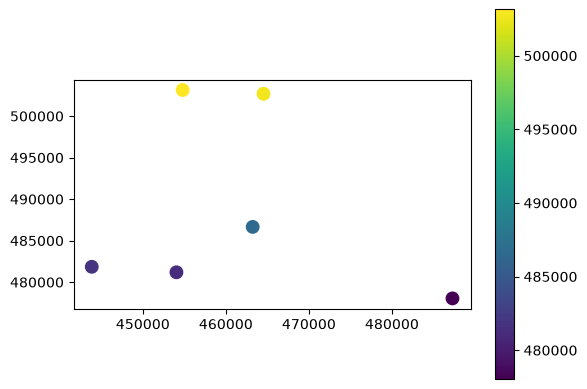

In [4]:
gauges = FeatureCollection.read_file(str(DATA / "coello-gauges.geojson"))
gauges.plot(column="y", markersize=80, legend=True)

We define the pipeline as a plain list of `(tool, parameters)` steps. It is validated **at construction** — an
unknown tool or a bad parameter fails right here, not halfway through a long run.

**This cell — define the pipeline (nothing runs yet):**

- Build a two-step `Pipeline` as a list of `(tool, parameters)` steps:
  - `interpolate_to_raster` — grid the scattered gauge points into a continuous raster (the `y` column,
    2000 m cells).
  - `slope` — compute the slope of that raster.
- Display the pipeline object — it is just the recipe; execution happens in the next cell.

In [5]:
quickstart = Pipeline(
    [
        ("interpolate_to_raster", {"column": "y", "cell_size": 2000.0}),
        ("slope", {}),
    ]
)
quickstart

Pipeline([('interpolate_to_raster', {'column': 'y', 'cell_size': 2000.0}), ('slope', {})])

`run` executes the pipeline over the input and returns a `RunResult`. Because the final step is a terrain op,
its array is materialized back into a georeferenced `Dataset` — so the output is a real raster we can plot.

**This cell — run it:**

- Execute the pipeline over the gauges with `run(...)`, which returns a `RunResult`.
- Take the first output (`result.outputs[0]`) — the slope raster.
- Plot it.

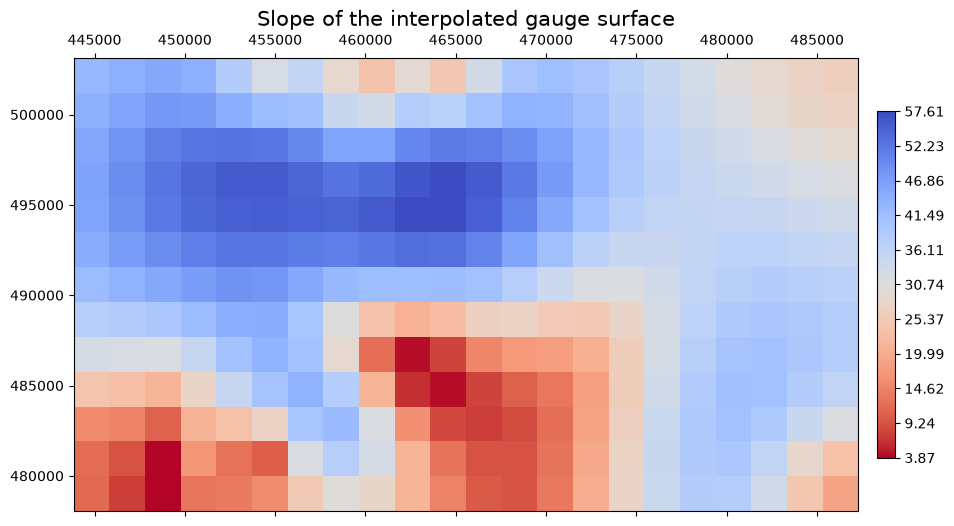

In [6]:
result = run(quickstart, gauges)
slope_raster = result.outputs[0]
slope_raster.plot(title="Slope of the interpolated gauge surface")

The gauge points became a continuous IDW surface, and `slope` turned that into a slope raster — one linear
chain, two input types, no manual glue. `result.outputs` holds the final object per input; `result.failures`
would hold `(input, error)` pairs under the default skip policy (none here).

## A raster pipeline on a real DEM

Now a `Dataset`-only chain on a real elevation model (the Rhine 5 km DEM). First, load and look at the DEM.

**This cell — load a real DEM:**

- Read the filled Rhine DEM into a `Dataset`.
- Plot it as the starting raster for the terrain pipeline.

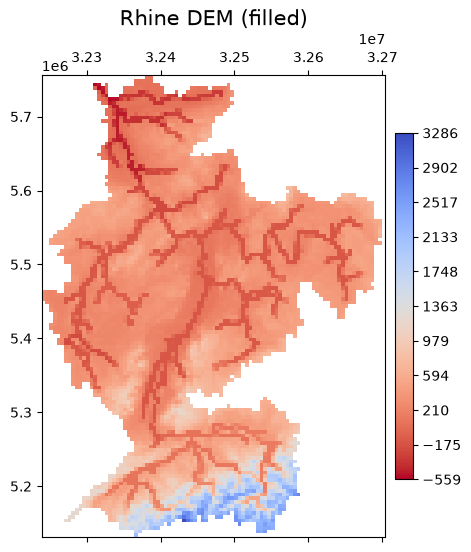

In [7]:
dem = Dataset.read_file(str(DATA / "dem" / "DEM5km_Rhine_burned_fill.tif"))
dem.plot(title="Rhine DEM (filled)")

A two-step terrain pipeline: smooth the DEM with a 3x3 mean (`focal_mean`), then compute `hillshade`. Each
step is one idea; the chain reads top to bottom.

**This cell — a raster terrain pipeline:**

- Build a two-step `Pipeline`:
  - `focal_mean` (radius 1) — smooth the DEM with a 3×3 moving average.
  - `hillshade` — compute shaded relief (sun at azimuth 315°, altitude 45°).
- Run it on the DEM and plot the hillshade in grayscale.

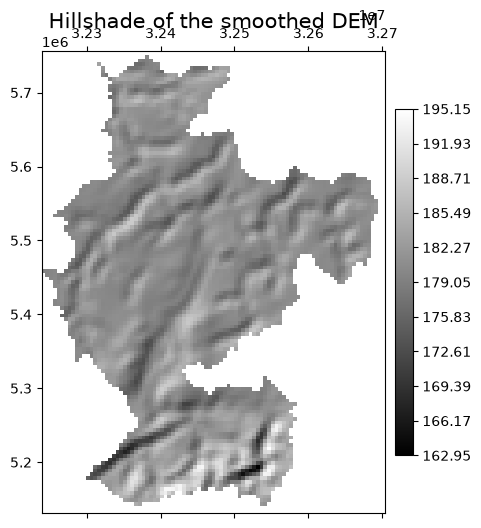

In [8]:
terrain = Pipeline(
    [
        ("focal_mean", {"radius": 1}),
        ("hillshade", {"azimuth": 315.0, "altitude": 45.0}),
    ]
)
hillshaded = run(terrain, dem).outputs[0]
hillshaded.plot(title="Hillshade of the smoothed DEM", cmap="gray")

The result is a shaded-relief raster. Swapping or reordering steps is a one-line edit to the pipeline list —
that is the point of describing the workflow as *data* rather than hand-written calls.

## Serialize a pipeline (the portable "model")

`to_yaml` writes the pipeline to a small, version-controllable file; `from_yaml` loads it back. Only
serialization-safe (scalar) parameters are allowed — `to_yaml` refuses to write anything it could not load back.

**This cell — serialize the pipeline:**

- Save the `terrain` pipeline to a portable YAML "model" file with `to_yaml`.
- Print the YAML so you can see the serialized `(tool, parameters)` steps.

In [9]:
yaml_path = Path("terrain.yaml")
terrain.to_yaml(str(yaml_path))
print(yaml_path.read_text())

pipeline:
- tool: focal_mean
  parameters:
    radius: 1
- tool: hillshade
  parameters:
    azimuth: 315.0
    altitude: 45.0



Loading it reconstructs an equivalent pipeline (validated again against the current registry).

**This cell — load it back:**

- Reconstruct the pipeline from the YAML file with `from_yaml` (re-validated against the registry).
- Confirm the reloaded pipeline equals the original — it round-trips exactly.

In [10]:
reloaded = Pipeline.from_yaml(str(yaml_path))
reloaded == terrain

True

`terrain.yaml` was just a scratch file for the demo — remove it so running this notebook leaves the tree
clean.

**This cell — cleanup:**

- Delete the scratch `terrain.yaml` file (demo housekeeping only).

In [11]:
yaml_path.unlink(missing_ok=True)

## Batch over many inputs

`run` accepts a single object, a `DatasetCollection`, or a **glob** of files. Here we smooth every raster in a
folder in one call. The `on_error` policy is `"skip"` by default — failures are collected in `result.failures`
and the batch keeps going; use `"raise"` to fail fast.

**This cell — batch over many rasters:**

- Define a one-step smoothing pipeline (`focal_mean`, radius 2).
- Run it as a **batch** over a folder of rasters (a `*.tif` glob).
- Report how many outputs succeeded and how many failed.

In [12]:
smooth = Pipeline([("focal_mean", {"radius": 2})])
batch = run(smooth, str(DATA / "crop_aligned_folder" / "*.tif"))
len(batch.outputs), len(batch.failures)

(6, 0)

Every input produced one output raster. Here is the first one.

**This cell — inspect a batch result:**

- Plot the first smoothed tile from the batch.

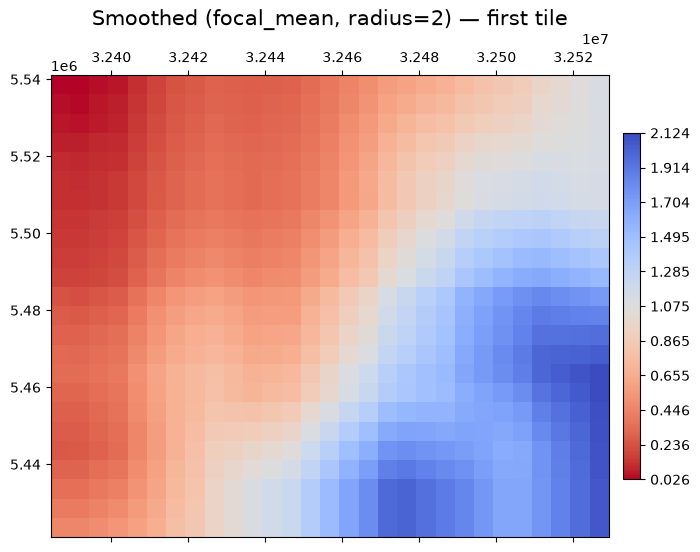

In [13]:
batch.outputs[0].plot(title="Smoothed (focal_mean, radius=2) — first tile")

## Vector tools

The vector input type has its own tools. `voronoi` builds Thiessen polygons around the gauge points; `quadtree`
adaptively bins them. Both take a `FeatureCollection` and return one.

**This cell — a vector tool:**

- Run a one-step `voronoi` pipeline on the gauge points to build Thiessen polygons.
- Plot the polygons (outlines only).

<Axes: >

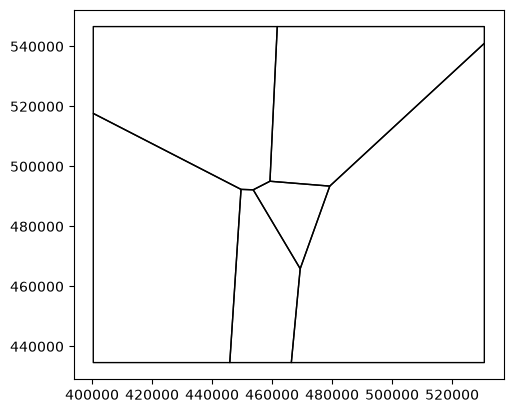

In [14]:
cells = run(Pipeline([("voronoi", {})]), gauges).outputs[0]
cells.plot(edgecolor="black", facecolor="none")

Each polygon is the region closest to one gauge — a common first step for turning point observations into
areal coverage.

## Provenance

Every run records, per step, the tool, its parameters, and the wall-clock time — and can re-emit the exact pipeline
that produced an output (reproducibility).

**This cell — read the provenance:**

- Take the provenance record from the earlier quickstart run.
- Show each step's tool, parameters, and wall-clock time as a table.

In [15]:
prov = result.provenance[0]
pd.DataFrame(
    [
        {"tool": s.tool, "parameters": s.parameters, "seconds": round(s.seconds, 4)}
        for s in prov.steps
    ]
)

,tool,parameters,seconds
0,interpolate_to_raster,"{'column': 'y', 'cell_size': 2000.0}",0.0852
1,slope,{},0.0017


`prov.to_pipeline()` returns a `Pipeline` equal to the one we ran, so a result's recipe can be replayed or
saved:

**This cell — provenance round-trips to a pipeline:**

- Rebuild a `Pipeline` from the provenance and confirm it equals the one we ran — the record faithfully
  captures the recipe that produced the output.

In [16]:
prov.to_pipeline() == quickstart

True

## The command line

The same three pieces are on the CLI:

| command | does |
|---------|------|
| `pyramids tools` | list the registered tools |
| `pyramids tool <name>` | print one tool's parameter schema |
| `pyramids run pipeline.yaml --inputs "*.tif" --out dir/` | run a pipeline (batched) over inputs, writing to `dir/` |

So a pipeline authored and saved in Python (or a GUI that reads the same YAML) runs unchanged from a shell script.

## Takeaway

You built and ran declarative pipelines over real data:

- **tools** are named, self-describing ops (`catalog` / `tool_names`);
- a **`Pipeline`** is a validated `(tool, parameters)` chain that can cross input types (points → raster → slope);
- **`run`** executes it over one input, a collection, or a glob, with a skip/raise error policy;
- pipelines **serialize** to YAML and back, and every run carries **provenance** you can replay.

Next: register your own `ToolMetadata` to add a tool, or drive `run(..., out=..., parallel=True)` to process a large
folder across a process pool.